# Exploratory Data Analysis: Titanic Passenger Dataset

**Goal:** understand who was aboard the Titanic, spot data quality issues, and find out what was actually associated with survival.

**Dataset:** 891 passengers, 15 raw columns — loaded from the local `titanic_raw.csv` file (Titanic passenger data, originally sourced from seaborn's sample datasets). Keep that CSV in the same folder as this notebook.

**Sections:** Load & First Look &rarr; Data Cleaning &rarr; Univariate Analysis &rarr; Bivariate/Multivariate Analysis &rarr; Key Insights &rarr; Next Steps


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)


## 1. Load & First Look

In [2]:
df = pd.read_csv('titanic_raw.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 891 rows x 15 columns


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary.missing_count > 0].sort_values('missing_pct', ascending=False)
missing_summary


,missing_count,missing_pct
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


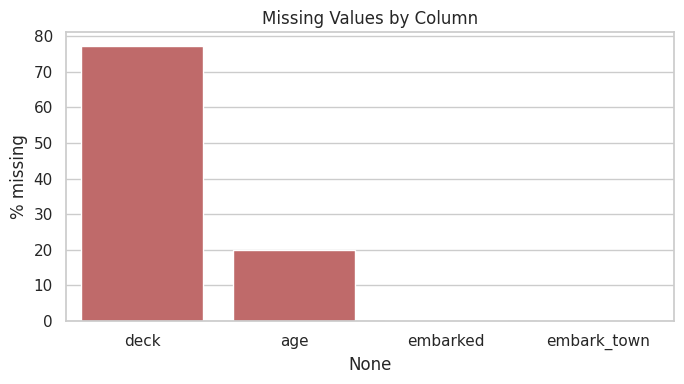

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=missing_summary.index, y=missing_summary['missing_pct'], color='indianred', ax=ax)
ax.set_ylabel('% missing')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.show()


**Cleaning decisions:**
- `deck` is missing for **77.2%** of rows — too sparse to impute meaningfully, so it's dropped.
- `age` is missing for **19.9%** of rows — imputed with the median age *within each class/sex group* rather than one global median, since typical age varies a lot across those groups.
- `embarked` is missing for only **2 rows** — negligible, so those rows are dropped rather than imputed.
- `class`, `who`, `adult_male`, `alive`, `embark_town` all duplicate information already captured by `pclass`, `sex`, `age`, `survived`, `embarked` — dropped to avoid redundancy.


In [7]:
df_clean = df.drop(columns=['deck', 'class', 'who', 'adult_male', 'alive', 'embark_town']).copy()
df_clean = df_clean.dropna(subset=['embarked'])
df_clean['age'] = df_clean.groupby(['pclass', 'sex'])['age'].transform(lambda s: s.fillna(s.median()))

print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
print(f"Duplicate rows: {df_clean.duplicated().sum()}")
print(f"Final shape: {df_clean.shape}")


Missing values remaining: 0
Duplicate rows: 118
Final shape: (889, 9)


## 3. Univariate Analysis

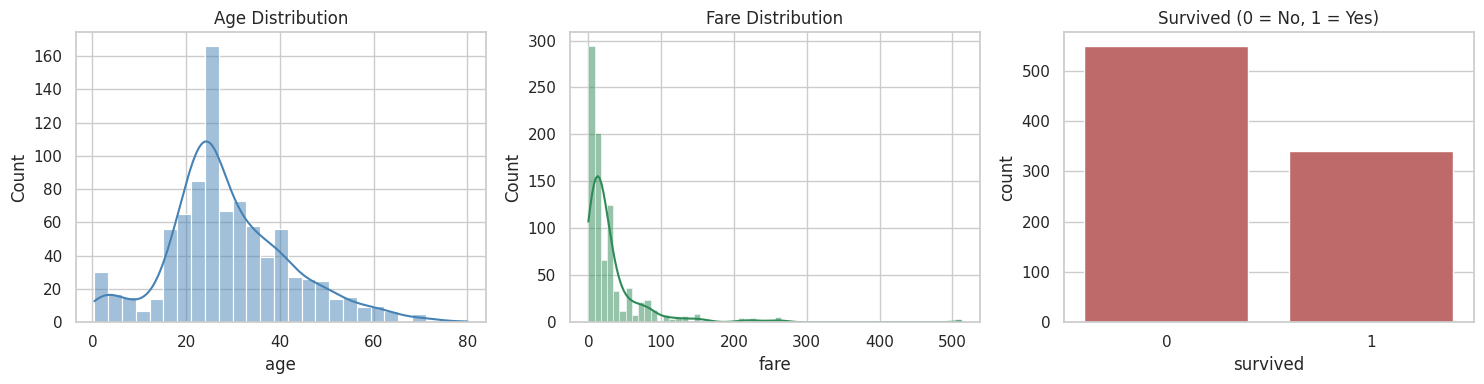

Age skew: 0.53   Fare skew: 4.80


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_clean['age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df_clean['fare'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Fare Distribution')

sns.countplot(x='survived', data=df_clean, ax=axes[2], color='indianred')
axes[2].set_title('Survived (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

print(f"Age skew: {df_clean['age'].skew():.2f}   Fare skew: {df_clean['fare'].skew():.2f}")


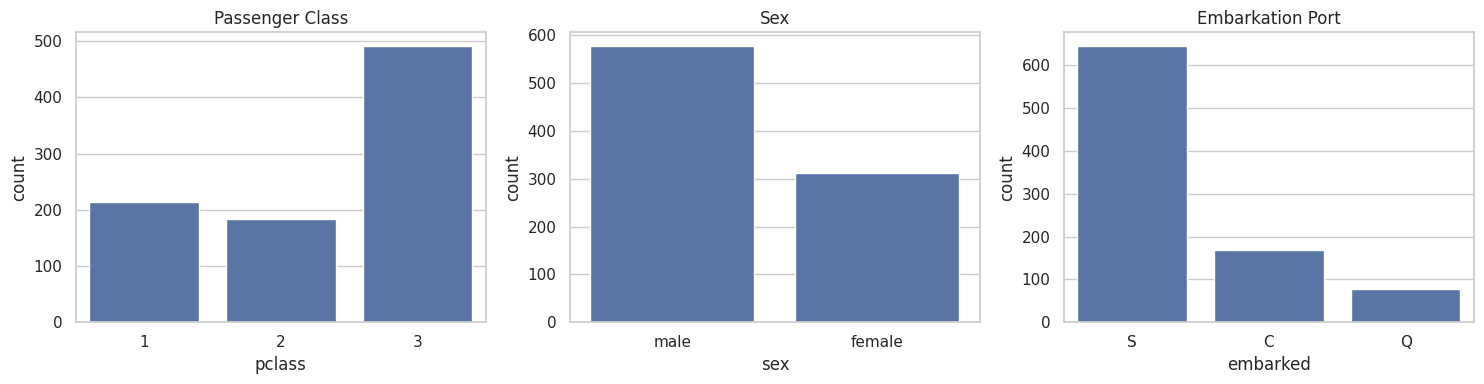

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x='pclass', data=df_clean, ax=axes[0])
axes[0].set_title('Passenger Class')

sns.countplot(x='sex', data=df_clean, ax=axes[1])
axes[1].set_title('Sex')

sns.countplot(x='embarked', data=df_clean, ax=axes[2])
axes[2].set_title('Embarkation Port')

plt.tight_layout()
plt.show()


## 4. Bivariate & Multivariate Analysis

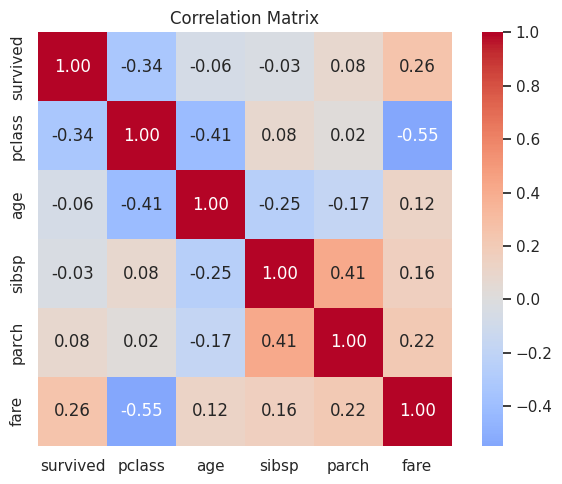

In [10]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


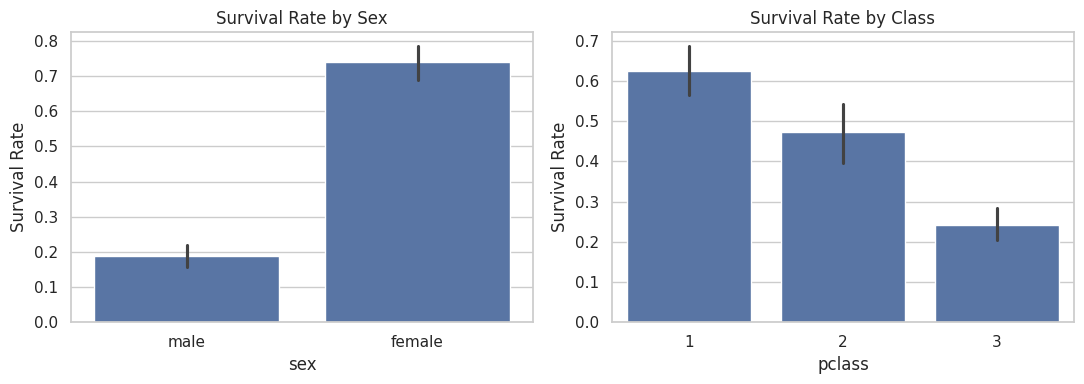

sex
female    0.740
male      0.189
Name: survived, dtype: float64

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(x='sex', y='survived', data=df_clean, ax=axes[0])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')

sns.barplot(x='pclass', y='survived', data=df_clean, ax=axes[1])
axes[1].set_title('Survival Rate by Class')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

df_clean.groupby('sex')['survived'].mean().round(3)


In [12]:
pivot = df_clean.pivot_table(index='pclass', columns='sex', values='survived', aggfunc='mean').round(3)
pivot


sex,female,male
pclass,,
1,0.967,0.369
2,0.921,0.157
3,0.500,0.135


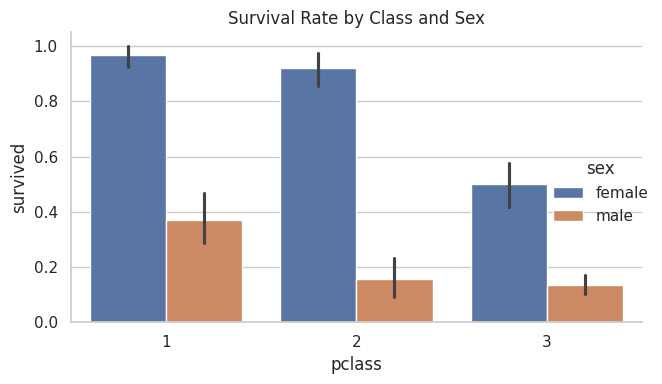

In [13]:
sns.catplot(x='pclass', y='survived', hue='sex', data=df_clean, kind='bar', height=4, aspect=1.4)
plt.title('Survival Rate by Class and Sex')
plt.tight_layout()
plt.show()


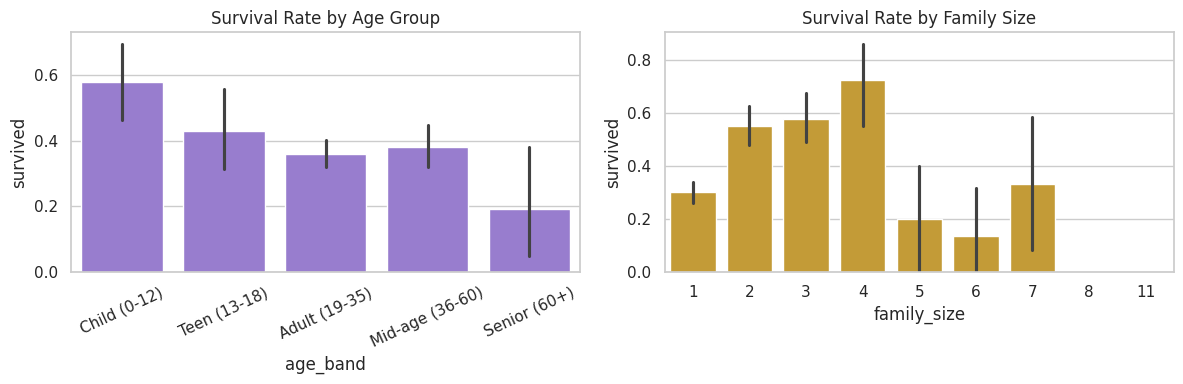

In [14]:
df_clean['age_band'] = pd.cut(
    df_clean['age'], bins=[0, 12, 18, 35, 60, 100],
    labels=['Child (0-12)', 'Teen (13-18)', 'Adult (19-35)', 'Mid-age (36-60)', 'Senior (60+)']
)
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x='age_band', y='survived', data=df_clean, ax=axes[0], color='mediumpurple')
axes[0].set_title('Survival Rate by Age Group')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(x='family_size', y='survived', data=df_clean, ax=axes[1], color='goldenrod')
axes[1].set_title('Survival Rate by Family Size')

plt.tight_layout()
plt.show()


## 5. Key Insights

Based on the 889-passenger cleaned dataset:

1. **Sex was the single strongest predictor of survival.** Women survived at **74.0%** vs. **18.9%** for men — a gap far bigger than any other factor examined here.
2. **Class mattered almost as much.** 1st class passengers survived at **62.6%**, vs **47.3%** in 2nd and **24.2%** in 3rd — and the gap holds up within each sex too (see the class x sex chart above).
3. **Fare is really a proxy for class.** Fare and class correlate at **-0.55**, and fare's own correlation with survival (0.26) is mostly explained by that link rather than fare itself mattering.
4. **Children had a real survival edge.** The Child (0-12) group survived at **58.0%**, clearly above teens and adults — consistent with "women and children first."
5. **Small families did better than solo travelers or big families.** Solo travelers survived at **30.1%**, families of 2-4 did best at **57.9%**, and families of 5+ dropped to **16.1%** — likely a mix of "someone to help you" and "harder to keep a big group together in the chaos."
6. **Age and fare are both right-skewed** (skew 0.53 and 4.8) — a long tail of older passengers / expensive fares pulls the mean above the median, so median is the more representative "typical" value for both.


## Next Steps

`sex`, `pclass`, `age_band`, and `family_size` look like the most promising features for a survival-prediction model. Reasonable next steps: encode the categoricals, engineer an `is_alone` flag, and try a baseline logistic regression or decision tree using just those four features before adding anything fancier.
